# 台大新生大樓電力使用行為分析

## 專案概述
本分析專案針對台灣大學新生大樓之電力使用資料進行系統性探討，結合每日與逐時電力數據，分析建築之能源使用模式、時間週期性特徵以及異常耗電行為，並進一步提出潛在節能與管理建議。

---

## 分析目標
- 🔍 **電力使用模式分析**：探討建築在日、週與季節尺度上的用電變化
- ⚡ **週期性行為辨識**：比較工作日與週末，以及日內24小時用電模式
- 📅 **假期效應分析**：分析寒暑假與學期間之用電差異
- 🚨 **異常用電偵測**：透過統計方法辨識異常高耗電或異常低耗電情形
- 🤖 **自動化偵測方法**：建立簡單規則式與統計方法進行用電行為辨識
- 🌱 **節能潛力評估**：從用電行為中找出可能的能源優化方向

---

## 資料來源
- 📊 **日用電資料**：2024/09/01 ～ 2025/09/01 每日用電紀錄（CSV）
- ⏱ **逐時用電資料**：2024年9月～2025年8月逐時電力監測資料（Excel）
- 🏫 **建築資訊**：台大新生大樓（校園建築）
- 🌦 **外部因素（選用）**：季節與氣候對用電之影響

---

## 方法說明
本研究主要使用功率資料（W）作為建築用電行為之代理指標，透過時間序列分析、統計方法與視覺化技術，探討能源使用特性。  
此外，採用平均值與標準差建立異常偵測門檻（Z-score），以識別潛在異常用電行為。

---

## 分析架構
1. 日資料分析（長期趨勢與週期性）
2. 逐時資料分析（日內用電模式）
3. 假期與季節效應分析
4. 異常用電偵測（rule-based + 統計方法）
5. 能源使用行為綜合解釋

Cell 1：套件匯入

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re
import sys
import subprocess
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def ensure_package(pkg_name):
    try:
        __import__(pkg_name)
    except ImportError:
        print(f"安裝套件：{pkg_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])
        __import__(pkg_name)

# 113 學年度行事曆 .xls 需要 xlrd
ensure_package("xlrd")

def normalize_colname(col):
    s = str(col)
    s = s.replace("\xa0", "").replace(" ", "").replace("\n", "").replace("\r", "").strip()
    return s

def standardize_columns(df):
    df = df.copy()
    df.columns = [normalize_colname(c) for c in df.columns]
    return df

def detect_column(columns, kind):
    cols = [normalize_colname(c) for c in columns]

    def has_any(text, keywords):
        return any(k in text for k in keywords)

    if kind == "date":
        priority = [
            ["日期時間"],
            ["時間"],
            ["日期"],
        ]
        fallback = lambda c: has_any(c, ["日期", "時間", "date", "time"])
    elif kind == "energy":
        priority = [
            ["用電度數"],
            ["用電量"],
            ["度數"],
            ["kWh"],
            ["KWH"],
        ]
        fallback = lambda c: (has_any(c.lower(), ["kwh"]) or (("用電" in c or "電量" in c) and ("度" in c or "量" in c)))
    elif kind == "power":
        priority = [
            ["功率kW"],
            ["功率KW"],
            ["功率"],
            ["需量kW"],
            ["需量KW"],
            ["kW"],
            ["KW"],
        ]
        fallback = lambda c: (("功率" in c or "需量" in c) or ("kw" in c.lower()))
    else:
        raise ValueError("Unknown kind")

    for pats in priority:
        for c in cols:
            if all(p.lower() in c.lower() for p in pats):
                return c
    for c in cols:
        if fallback(c):
            return c
    raise KeyError(f"找不到 {kind} 欄位。現有欄位：{cols}")


Cell 2：讀取日資料 24-25.csv

In [2]:
# 自動尋找專案資料夾與日資料
candidate_roots = [
    Path.cwd(),
    Path.cwd() / "環保能源",
    Path("/mnt/data"),
    Path(r"C:\Users\admin\Desktop\環保能源"),
]

def find_first(patterns, roots):
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = sorted(root.rglob(pattern))
            if matches:
                return matches[0]
    return None

day_path = find_first(["24-25.csv", "*.csv"], candidate_roots)
if day_path is None:
    raise FileNotFoundError("找不到日資料 CSV，請確認 24-25.csv 已放在專案資料夾或其子資料夾中。")

base_dir = day_path.parent.parent if day_path.parent.name.lower() == "day" else day_path.parent
print("使用的 base_dir：", base_dir)
print("使用的日資料：", day_path)

# 有些檔案第一列是說明，有些不是，因此兩種方式都試
daily = None
for skip in [1, 0]:
    try:
        tmp = pd.read_csv(day_path, encoding="utf-8-sig", skiprows=skip)
        tmp = standardize_columns(tmp)
        # 如果欄位太怪，至少要能偵測日期與其中一種電力欄位
        _ = detect_column(tmp.columns, "date")
        try:
            _ = detect_column(tmp.columns, "energy")
        except Exception:
            _ = detect_column(tmp.columns, "power")
        daily = tmp
        print(f"成功讀取日資料，skiprows={skip}")
        break
    except Exception as e:
        print(f"skiprows={skip} 讀取失敗：{e}")

if daily is None:
    raise ValueError("無法正確解析日資料 CSV，請檢查檔案格式。")

print("日資料欄位：", daily.columns.tolist())
print(daily.head())


['日期時間', '功率kW', '電表數值', '用電度數', '功因%', 'I_r', 'I_s', 'I_t', 'V_rs', 'V_st', 'V_tr', '總視在功率kVa', '總無效功率kVar']
       日期時間   功率kW      電表數值     用電度數  功因%    I_r    I_s    I_t    V_rs  \
0  2024/9/1  10.80  10355.95   264.62   93  15.88  21.20  15.20  377.70   
1  2024/9/2  11.36  10620.57  1976.91   95  18.14  21.40  14.87  378.54   
2  2024/9/3  10.11  12597.48  2151.05   92  16.52  16.70  15.79  380.99   
3  2024/9/4   9.83  14748.53  1985.22   92  16.26  16.25  15.70  377.48   
4  2024/9/5  11.49  16733.75  2364.58   94  17.49  21.34  15.90  379.89   

     V_st    V_tr  總視在功率kVa  總無效功率kVar  
0  378.60  377.63     11.51       3.75  
1  379.25  378.40     11.95       3.72  
2  381.95  380.97     10.94       4.06  
3  378.39  377.31     10.58       3.78  
4  380.74  379.81     12.16       3.93  


Cell 3：確認日資料欄位，這格是為了避免抓錯欄位。

In [3]:
# 自動偵測日資料欄位
date_col_daily = detect_column(daily.columns, "date")
energy_col_daily = detect_column(daily.columns, "energy")
power_col_daily = detect_column(daily.columns, "power")

print("日期欄:", date_col_daily)
print("日用電欄:", energy_col_daily)
print("功率欄:", power_col_daily)


日期欄: 日期時間
日用電欄: 用電度數
功率欄: 功率kW


Cell 4：清理日資料

In [4]:
daily[date_col_daily] = pd.to_datetime(daily[date_col_daily], errors="coerce")
daily[energy_col_daily] = pd.to_numeric(daily[energy_col_daily], errors="coerce")
daily[power_col_daily] = pd.to_numeric(daily[power_col_daily], errors="coerce")

daily = daily.dropna(subset=[date_col_daily]).copy()

# 若 energy 欄缺值較多，仍保留；後續以可用資料分析
daily["energy_kWh"] = daily[energy_col_daily]
daily["power_kW"] = daily[power_col_daily]

print(daily[[date_col_daily, "energy_kWh", "power_kW"]].head())
print(daily.shape)


        日期時間  energy_kWh  power_kW
0 2024-09-01      264.62     10.80
1 2024-09-02     1976.91     11.36
2 2024-09-03     2151.05     10.11
3 2024-09-04     1985.22      9.83
4 2024-09-05     2364.58     11.49
(366, 15)


Cell 5：新增時間欄位（日資料）

In [5]:
daily["year"] = daily[date_col_daily].dt.year
daily["month"] = daily[date_col_daily].dt.month
daily["day"] = daily[date_col_daily].dt.day
daily["weekday_num"] = daily[date_col_daily].dt.weekday
daily["weekday"] = daily["weekday_num"].map({
    0: "星期一", 1: "星期二", 2: "星期三",
    3: "星期四", 4: "星期五", 5: "星期六", 6: "星期日"
})
daily["is_weekend"] = daily["weekday_num"].isin([5, 6])

daily.head()

,日期時間,功率kW,電表數值,用電度數,功因%,I_r,I_s,I_t,V_rs,V_st,...,總視在功率kVa,總無效功率kVar,energy_kWh,power_kW,year,month,day,weekday_num,weekday,is_weekend
0,2024-09-01,10.80,10355.95,264.62,93,15.88,21.20,15.20,377.70,378.60,...,11.51,3.75,264.62,10.80,2024,9,1,6,星期日,True
1,2024-09-02,11.36,10620.57,1976.91,95,18.14,21.40,14.87,378.54,379.25,...,11.95,3.72,1976.91,11.36,2024,9,2,0,星期一,False
2,2024-09-03,10.11,12597.48,2151.05,92,16.52,16.70,15.79,380.99,381.95,...,10.94,4.06,2151.05,10.11,2024,9,3,1,星期二,False
3,2024-09-04,9.83,14748.53,1985.22,92,16.26,16.25,15.70,377.48,378.39,...,10.58,3.78,1985.22,9.83,2024,9,4,2,星期三,False
4,2024-09-05,11.49,16733.75,2364.58,94,17.49,21.34,15.90,379.89,380.74,...,12.16,3.93,2364.58,11.49,2024,9,5,3,星期四,False


Cell 6：整體時間序列圖（日資料，以用電度數為主）

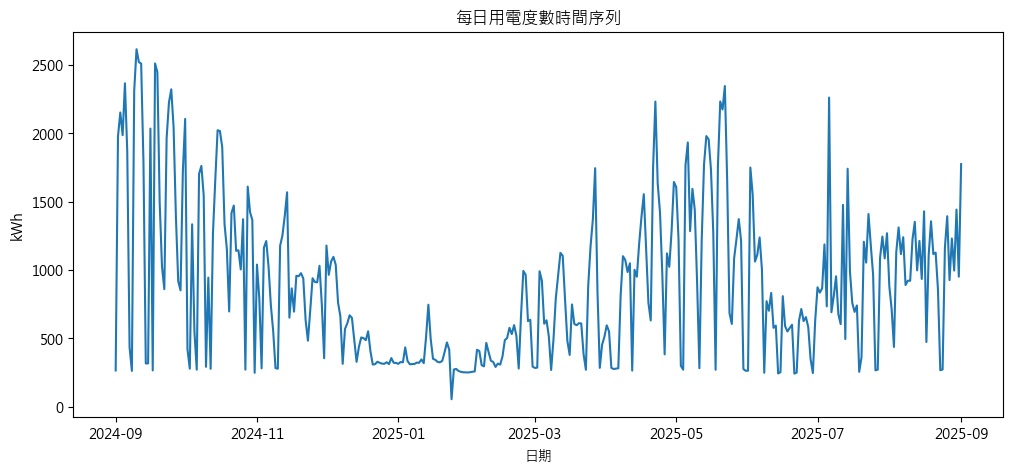

In [6]:
plt.figure(figsize=(12,5))
plt.plot(daily[date_col_daily], daily["energy_kWh"])
plt.title("每日用電度數時間序列")
plt.xlabel("日期")
plt.ylabel("kWh")
plt.show()

Cell 7：星期一到星期日平均（日資料，用電度數）

weekday
星期一    1071.628113
星期二    1121.227115
星期三    1065.875577
星期四    1019.346346
星期五     827.169808
星期六     563.576731
星期日     503.597170
Name: energy_kWh, dtype: float64


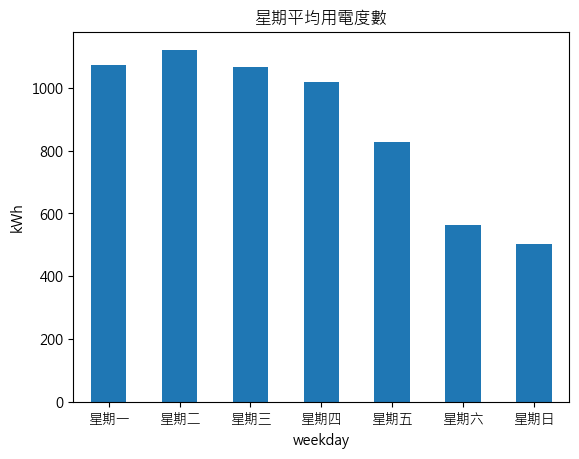

In [7]:
weekday_avg = daily.groupby("weekday")["energy_kWh"].mean()
weekday_avg = weekday_avg.reindex(["星期一","星期二","星期三","星期四","星期五","星期六","星期日"])

print(weekday_avg)

weekday_avg.plot(kind="bar")
plt.title("星期平均用電度數")
plt.ylabel("kWh")
plt.xticks(rotation=0)
plt.show()

Cell 8：平日 vs 週末（日資料，用電度數）

平日    1021.243180
週末     533.301333
Name: energy_kWh, dtype: float64


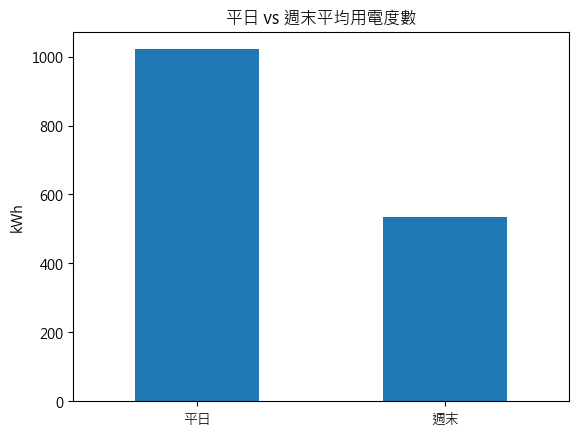

In [8]:
week_compare = daily.groupby("is_weekend")["energy_kWh"].mean()
week_compare.index = ["平日", "週末"]

print(week_compare)

week_compare.plot(kind="bar")
plt.title("平日 vs 週末平均用電度數")
plt.ylabel("kWh")
plt.xticks(rotation=0)
plt.show()

Cell 9：每月平均（日資料，用電度數）

month
1      340.266452
2      451.957143
3      699.219677
4      986.821000
5     1279.949355
6      674.248667
7      936.057419
8     1011.971613
9     1596.884516
10    1160.360968
11     849.889333
12     541.662258
Name: energy_kWh, dtype: float64


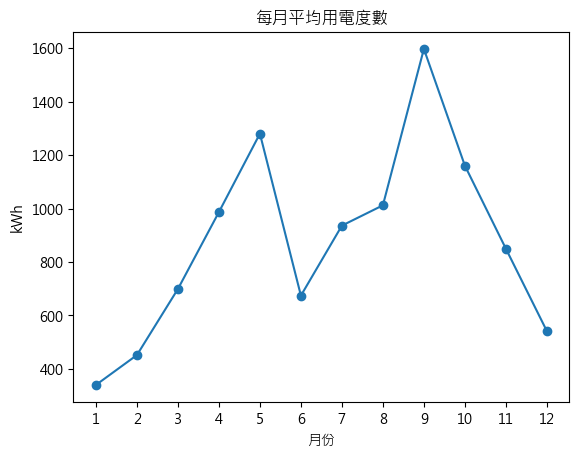

In [9]:
month_avg = daily.groupby("month")["energy_kWh"].mean()

print(month_avg)

month_avg.plot(marker="o")
plt.title("每月平均用電度數")
plt.xlabel("月份")
plt.ylabel("kWh")
plt.xticks(range(1,13))
plt.show()

Cell 10：依台大 113 學年度行事曆建立 calendar features（日資料）

In [10]:
# 依台大 113 學年度行事曆建立 calendar features（日資料）
calendar_path = find_first(
    ["113學年度行事曆C1140103版.xls", "*113*行事曆*.xls", "*行事曆*.xls", "*calendar*.xls", "*calendar*.xlsx"],
    candidate_roots,
)

if calendar_path is None:
    raise FileNotFoundError("找不到 113 學年度行事曆檔案，請將行事曆放在專案資料夾或 Notebook 同層。")

print("使用的行事曆：", calendar_path)

calendar_raw = pd.read_excel(calendar_path, header=None, engine="xlrd" if str(calendar_path).lower().endswith(".xls") else None)

# 攤平成單欄字串，便於解析
calendar_flat = calendar_raw.astype(str).stack().reset_index(drop=True)

records = []
for row in calendar_flat:
    row = str(row).strip()
    match = re.search(r"(\d{1,2})月(\d{1,2})日\s*(.*)", row)
    if match:
        month = int(match.group(1))
        day = int(match.group(2))
        desc = match.group(3).strip()
        year = 2024 if month >= 8 else 2025  # 113 學年度：2024/08 ~ 2025/07
        try:
            date = pd.Timestamp(year=year, month=month, day=day)
            records.append({"date": date.normalize(), "text": row, "event_desc": desc})
        except ValueError:
            pass

calendar_df = pd.DataFrame(records).drop_duplicates(subset=["date", "text"]).sort_values("date").reset_index(drop=True)

# 事件分類
calendar_df["is_holiday"] = calendar_df["text"].str.contains(
    "放假|休假|補假|春節|清明|端午|中秋|國慶|和平紀念日|兒童節", regex=True, na=False
)
calendar_df["is_exam"] = calendar_df["text"].str.contains(
    "期中|期末", regex=True, na=False
)
calendar_df["is_vacation"] = calendar_df["text"].str.contains(
    "寒假|暑假", regex=True, na=False
)
calendar_df["is_start"] = calendar_df["text"].str.contains(
    "開學|開始上課", regex=True, na=False
)
calendar_df["is_course_selection"] = calendar_df["text"].str.contains(
    "選課", regex=True, na=False
)

# 同一天可能有多筆事件，需聚合成單日標籤
calendar_daily = calendar_df.groupby("date").agg({
    "text": lambda x: "；".join(sorted(set(map(str, x)))),
    "event_desc": lambda x: "；".join(sorted(set([str(v) for v in x if str(v) != 'nan']))),
    "is_holiday": "max",
    "is_exam": "max",
    "is_vacation": "max",
    "is_start": "max",
    "is_course_selection": "max",
}).reset_index()

daily["date"] = pd.to_datetime(daily[date_col_daily]).dt.normalize()
daily = daily.merge(calendar_daily, on="date", how="left")

for col in ["is_holiday", "is_exam", "is_vacation", "is_start", "is_course_selection"]:
    daily[col] = daily[col].fillna(False)

daily["day_type"] = "一般日"
daily.loc[daily["is_weekend"], "day_type"] = "週末"
daily.loc[daily["is_holiday"], "day_type"] = "國定/校定假日"
daily.loc[daily["is_vacation"], "day_type"] = "寒暑假"
daily.loc[daily["is_exam"], "day_type"] = "考試相關"
daily.loc[daily["is_course_selection"], "day_type"] = "選課/註冊相關"

print("calendar_df 筆數：", len(calendar_df))
print("calendar_daily 筆數：", len(calendar_daily))
display(calendar_daily.head(10))
daily[["is_holiday", "is_exam", "is_vacation", "is_start", "is_course_selection"]].sum()

is_summer_vacation    84
is_winter_vacation    56
dtype: int64

Cell 11：假期與校務事件效應（日資料，用電度數）

暑假       861.807381
寒假       338.075179
非寒暑假    1023.084425
dtype: float64


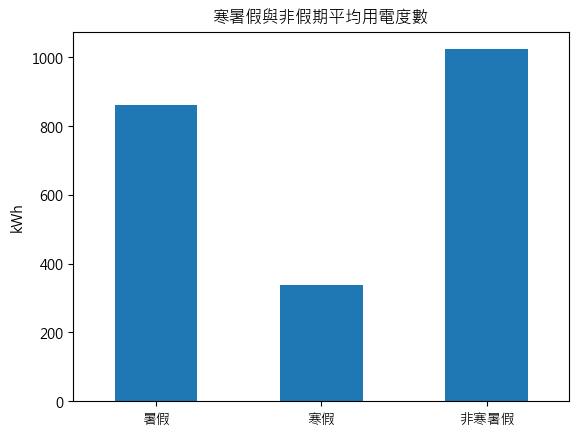

In [11]:
calendar_compare = daily.groupby("day_type")["energy_kWh"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
print(calendar_compare)

calendar_compare["mean"].plot(kind="bar")
plt.title("不同日型平均用電度數")
plt.ylabel("kWh")
plt.xticks(rotation=20)
plt.show()

vacation_compare = {
    "寒暑假": daily.loc[daily["is_vacation"], "energy_kWh"].mean(),
    "國定/校定假日": daily.loc[daily["is_holiday"], "energy_kWh"].mean(),
    "考試相關": daily.loc[daily["is_exam"], "energy_kWh"].mean(),
    "一般學期日": daily.loc[~(daily["is_vacation"] | daily["is_holiday"] | daily["is_exam"]), "energy_kWh"].mean()
}
vacation_compare = pd.Series(vacation_compare)
print(vacation_compare)

vacation_compare.plot(kind="bar")
plt.title("行事曆事件平均用電比較")
plt.ylabel("kWh")
plt.xticks(rotation=0)
plt.show()

Cell 12：異常日偵測（日資料，用電度數）

In [12]:
mean_val = daily["energy_kWh"].mean()
std_val = daily["energy_kWh"].std()

high_threshold = mean_val + 2 * std_val
low_threshold = mean_val - 2 * std_val

daily["anomaly"] = (daily["energy_kWh"] > high_threshold) | (daily["energy_kWh"] < low_threshold)

anomalies = daily.loc[daily["anomaly"], [date_col_daily, "energy_kWh"]].copy()

print("高門檻:", high_threshold)
print("低門檻:", low_threshold)
print(anomalies.head(20))
print("異常日數量:", len(anomalies))

高門檻: 2015.6434587670417
低門檻: -253.12373199108538
          日期時間  energy_kWh
2   2024-09-03     2151.05
4   2024-09-05     2364.58
8   2024-09-09     2310.26
9   2024-09-10     2613.71
10  2024-09-11     2519.92
11  2024-09-12     2508.64
15  2024-09-16     2033.18
17  2024-09-18     2509.55
18  2024-09-19     2446.58
23  2024-09-24     2224.35
24  2024-09-25     2320.35
25  2024-09-26     2045.09
30  2024-10-01     2103.81
44  2024-10-15     2021.39
233 2025-04-22     2231.08
261 2025-05-20     2231.49
262 2025-05-21     2173.04
263 2025-05-22     2344.47
308 2025-07-06     2260.13
異常日數量: 19


Cell 13：異常日視覺化（日資料，用電度數）

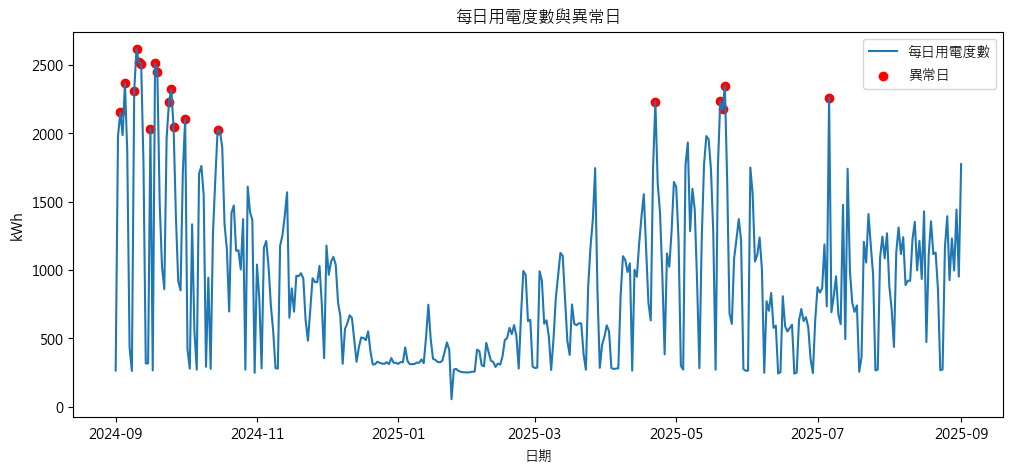

In [13]:
plt.figure(figsize=(12,5))
plt.plot(daily[date_col_daily], daily["energy_kWh"], label="每日用電度數")
plt.scatter(anomalies[date_col_daily], anomalies["energy_kWh"], color="red", label="異常日")
plt.title("每日用電度數與異常日")
plt.xlabel("日期")
plt.ylabel("kWh")
plt.legend()
plt.show()

Cell 13-1：用電與行事曆事件對應（日資料）

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(daily["date"], daily["energy_kWh"], label="每日用電度數", linewidth=1)

holiday_pts = daily.loc[daily["is_holiday"], ["date", "energy_kWh"]].dropna()
exam_pts = daily.loc[daily["is_exam"], ["date", "energy_kWh"]].dropna()
vac_pts = daily.loc[daily["is_vacation"], ["date", "energy_kWh"]].dropna()

if not holiday_pts.empty:
    plt.scatter(holiday_pts["date"], holiday_pts["energy_kWh"], s=16, label="國定/校定假日")
if not exam_pts.empty:
    plt.scatter(exam_pts["date"], exam_pts["energy_kWh"], s=16, label="考試相關")
if not vac_pts.empty:
    plt.scatter(vac_pts["date"], vac_pts["energy_kWh"], s=16, label="寒暑假")

plt.title("每日用電與行事曆事件對應")
plt.xlabel("日期")
plt.ylabel("kWh")
plt.legend()
plt.tight_layout()
plt.show()

Cell 14：列出逐時資料檔名

In [14]:
hour_dir_candidates = [base_dir / "hour", base_dir]
hourly_files = []

for root in hour_dir_candidates:
    if root.exists():
        hourly_files = sorted(
            [str(p) for p in root.glob("*.xls") if not p.name.startswith("~$")],
            key=lambda x: int(Path(x).stem) if Path(x).stem.isdigit() else Path(x).stem
        )
        if hourly_files:
            hour_dir = root
            break

if not hourly_files:
    raise FileNotFoundError("找不到逐時 .xls 檔案，請確認 hour 資料夾存在且內有每月逐時資料。")

print("逐時資料夾：", hour_dir)
print(hourly_files)

['C:\\Users\\admin\\Desktop\\環保能源\\hour\\1.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\2.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\3.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\4.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\5.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\6.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\7.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\8.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\9.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\10.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\11.xls', 'C:\\Users\\admin\\Desktop\\環保能源\\hour\\12.xls']


Cell 15：讀取所有逐時 .xls（從 hour 資料夾自動抓取）

In [15]:
import pandas as pd

def make_unique_columns(columns):
    seen = {}
    new_cols = []
    for col in columns:
        col = str(col).strip()
        if col in seen:
            seen[col] += 1
            new_cols.append(f"{col}_{seen[col]}")
        else:
            seen[col] = 0
            new_cols.append(col)
    return new_cols

hourly_list = []

for file in hourly_files:
    fname = os.path.basename(file)
    print(f"處理：{fname}")

    tables = pd.read_html(file)

    # 選最大 table
    temp = max(tables, key=lambda x: x.shape[0])

    # 找欄名列（包含「日期」）
    header_row = None
    for i in range(len(temp)):
        row = temp.iloc[i].astype(str).tolist()
        if any("日期" in str(x) for x in row):
            header_row = i
            break

    if header_row is None:
        print(f"❌ 找不到欄名：{fname}")
        continue

    temp.columns = temp.iloc[header_row]
    temp = temp.iloc[header_row + 1:].reset_index(drop=True)

    temp.columns = (
        temp.columns.astype(str)
        .str.replace('\xa0', '', regex=True)
        .str.strip()
    )
    temp.columns = make_unique_columns(temp.columns)
    temp["source_file"] = fname
    temp = temp.reset_index(drop=True)

    hourly_list.append(temp)

if not hourly_list:
    raise ValueError("逐時資料讀取失敗，沒有成功解析任何 .xls 檔案。")

hourly = pd.concat(hourly_list, ignore_index=True, sort=False)

print("\n欄位：")
print(hourly.columns.tolist())

print("\n前五列：")
print(hourly.head())

print("\n資料大小：", hourly.shape)

處理：1.xls
處理：10.xls
處理：11.xls
處理：12.xls
處理：2.xls
處理：3.xls
處理：4.xls
處理：5.xls
處理：6.xls
處理：7.xls
處理：8.xls
處理：9.xls

欄位：
['日期時間', '功率kW', '電表數值', '用電度數', '功因%', 'I_r', 'I_s', 'I_t', 'V_rs', 'V_st', 'V_tr', '總視在功率kVa', '總無效功率kVar', 'source_file']

前五列：
               日期時間   功率kW       電表數值   用電度數 功因%    I_r    I_s    I_t    V_rs  \
0  2025/01/01 00:00  13.29  136345.05  14.03  88  23.01  21.76  22.93  383.74   
1  2025/01/01 01:00  13.06  136359.08  14.09  89  22.42  21.55  21.61  383.32   
2  2025/01/01 02:00  14.12  136373.17  15.05  89  25.55  21.73  23.35  384.29   
3  2025/01/01 03:00  12.67  136388.22  13.64  88  21.88  21.24  21.23  385.08   
4  2025/01/01 04:00  14.52  136401.86  14.02  88  26.76  21.27  25.06  386.10   

     V_st    V_tr 總視在功率kVa 總無效功率kVar source_file  
0  384.49  383.71    15.00      6.70       1.xls  
1  384.09  383.30    14.61      6.36       1.xls  
2  384.87  384.17    15.82      6.81       1.xls  
3  385.53  384.87    14.39      6.65       1.xls  
4  386.63  

Cell 16：確認逐時資料欄位（功率與用電度數）

In [16]:
# 自動偵測逐時資料欄位
hourly = standardize_columns(hourly)

date_col_hourly = detect_column(hourly.columns, "date")
energy_col_hourly = detect_column(hourly.columns, "energy")
power_col_hourly = detect_column(hourly.columns, "power")

print("逐時日期欄:", date_col_hourly)
print("逐時用電欄:", energy_col_hourly)
print("逐時功率欄:", power_col_hourly)

hourly["日期時間"] = pd.to_datetime(hourly[date_col_hourly], errors="coerce")
hourly["功率kW"] = pd.to_numeric(hourly[power_col_hourly], errors="coerce")
hourly["用電度數"] = pd.to_numeric(hourly[energy_col_hourly], errors="coerce")

hourly = hourly.dropna(subset=["日期時間", "功率kW"]).copy()

print(hourly[["日期時間", "功率kW", "用電度數"]].head())
print(hourly.shape)


                 日期時間   功率kW   用電度數
0 2025-01-01 00:00:00  13.29  14.03
1 2025-01-01 01:00:00  13.06  14.09
2 2025-01-01 02:00:00  14.12  15.05
3 2025-01-01 03:00:00  12.67  13.64
4 2025-01-01 04:00:00  14.52  14.02
(8738, 14)


Cell 17：清理逐時資料

In [17]:
hourly["hour"] = hourly["日期時間"].dt.hour
hourly["weekday_num"] = hourly["日期時間"].dt.weekday
hourly["weekday"] = hourly["weekday_num"].map({
    0: "星期一", 1: "星期二", 2: "星期三",
    3: "星期四", 4: "星期五", 5: "星期六", 6: "星期日"
})
hourly["is_weekend"] = hourly["weekday_num"].isin([5, 6])

hourly.head()

,日期時間,功率kW,電表數值,用電度數,功因%,I_r,I_s,I_t,V_rs,V_st,V_tr,總視在功率kVa,總無效功率kVar,source_file,hour,weekday_num,weekday,is_weekend
0,2025-01-01 00:00:00,13.29,136345.05,14.03,88,23.01,21.76,22.93,383.74,384.49,383.71,15.00,6.70,1.xls,0,2,星期三,False
1,2025-01-01 01:00:00,13.06,136359.08,14.09,89,22.42,21.55,21.61,383.32,384.09,383.30,14.61,6.36,1.xls,1,2,星期三,False
2,2025-01-01 02:00:00,14.12,136373.17,15.05,89,25.55,21.73,23.35,384.29,384.87,384.17,15.82,6.81,1.xls,2,2,星期三,False
3,2025-01-01 03:00:00,12.67,136388.22,13.64,88,21.88,21.24,21.23,385.08,385.53,384.87,14.39,6.65,1.xls,3,2,星期三,False
4,2025-01-01 04:00:00,14.52,136401.86,14.02,88,26.76,21.27,25.06,386.10,386.63,385.99,16.39,7.12,1.xls,4,2,星期三,False


Cell 18：24 小時平均曲線（逐時資料）

hour
0     13.907931
1     14.258984
2     13.987671
3     13.693644
4     13.555220
5     13.666621
6     12.797967
7     18.312782
8     36.940882
9     53.443278
10    64.673361
11    69.696271
12    70.240028
13    64.849586
14    67.400358
15    65.848154
16    62.197769
17    53.690412
18    32.881401
19    35.017418
20    33.106538
21    30.278292
22    13.727775
23    13.070466
Name: 功率kW, dtype: float64


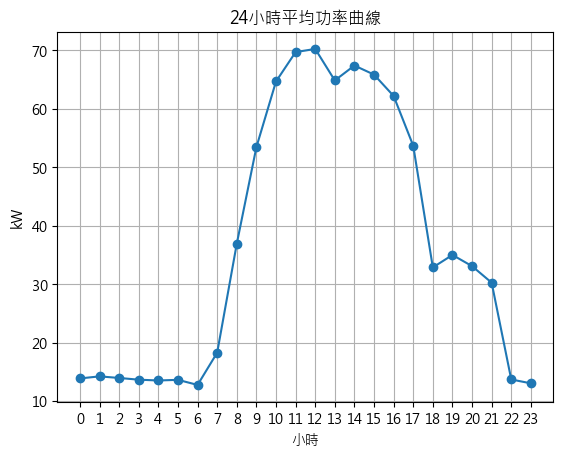

In [18]:
hour_avg = hourly.groupby("hour")["功率kW"].mean()

print(hour_avg)

hour_avg.plot(marker="o")
plt.title("24小時平均功率曲線")
plt.xlabel("小時")
plt.ylabel("kW")
plt.xticks(range(24))
plt.grid(True)
plt.show()

Cell 19：平日 vs 週末 24 小時曲線（逐時資料）

             平日         週末
hour                      
0     13.818993  14.126606
1     14.237992  14.310762
2     13.922423  14.149238
3     13.526692  14.107048
4     13.308649  14.163429


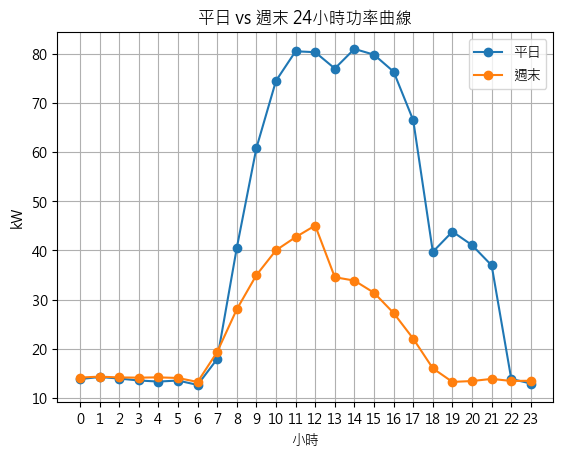

In [19]:
hour_week = hourly.groupby(["hour", "is_weekend"])["功率kW"].mean().unstack()
hour_week.columns = ["平日", "週末"]

print(hour_week.head())

hour_week.plot(marker="o")
plt.title("平日 vs 週末 24小時功率曲線")
plt.xlabel("小時")
plt.ylabel("kW")
plt.xticks(range(24))
plt.grid(True)
plt.show()

Cell 20：夜間基載與尖峰（逐時資料）
(本研究將凌晨 0–5 時定義為夜間基載時段，將 9–17 時定義為白天主要使用時段，以比較建築在最低載與主要活動時段之用電差異。晚間 18–23 時因可能同時受到延伸活動與逐步降載影響，故未納入日夜比指標，而另可作為晚間用電行為分析之補充時段。)

In [20]:
night_base = hourly.loc[hourly["hour"].between(0, 5), "功率kW"].mean()
day_load = hourly.loc[hourly["hour"].between(9, 17), "功率kW"].mean()

print("夜間基載平均 kW：", night_base)
print("白天時段平均 kW：", day_load)
print("日夜比：", day_load / night_base if night_base != 0 else None)

夜間基載平均 kW： 13.84537971805366
白天時段平均 kW： 63.55256967840735
日夜比： 4.590164442766281


Cell 21：逐時資料的異常小時（選做）

In [21]:
hour_mean = hourly.groupby("hour")["功率kW"].transform("mean")
hour_std = hourly.groupby("hour")["功率kW"].transform("std")
hour_threshold = hour_mean + 2 * hour_std

hourly["threshold"] = hour_threshold
hourly["anomaly_better"] = hourly["功率kW"] > hourly["threshold"]

hourly_anomaly2 = hourly.loc[
    hourly["anomaly_better"],
    ["日期時間", "hour", "功率kW", "threshold", "source_file"]
].copy()

print("改良後異常數量：", len(hourly_anomaly2))
print(hourly_anomaly2.head(30))

改良後異常數量： 433
                    日期時間  hour    功率kW   threshold source_file
334  2025-01-14 22:00:00    22   26.99   26.809101       1.xls
335  2025-01-14 23:00:00    23   27.73   24.130037       1.xls
336  2025-01-15 00:00:00     0   38.63   24.495557       1.xls
337  2025-01-15 01:00:00     1   39.09   23.863284       1.xls
338  2025-01-15 02:00:00     2   38.19   23.251485       1.xls
339  2025-01-15 03:00:00     3   38.52   22.059239       1.xls
340  2025-01-15 04:00:00     4   27.80   23.058445       1.xls
341  2025-01-15 05:00:00     5   27.32   22.673666       1.xls
342  2025-01-15 06:00:00     6   26.98   22.560315       1.xls
759  2024-10-01 14:00:00    14  199.49  177.308265      10.xls
760  2024-10-01 15:00:00    15  193.92  173.936820      10.xls
761  2024-10-01 16:00:00    16  186.48  165.658625      10.xls
762  2024-10-01 17:00:00    17  148.64  141.789296      10.xls
763  2024-10-01 18:00:00    18  105.60   98.306473      10.xls
764  2024-10-01 19:00:00    19  120.71  11

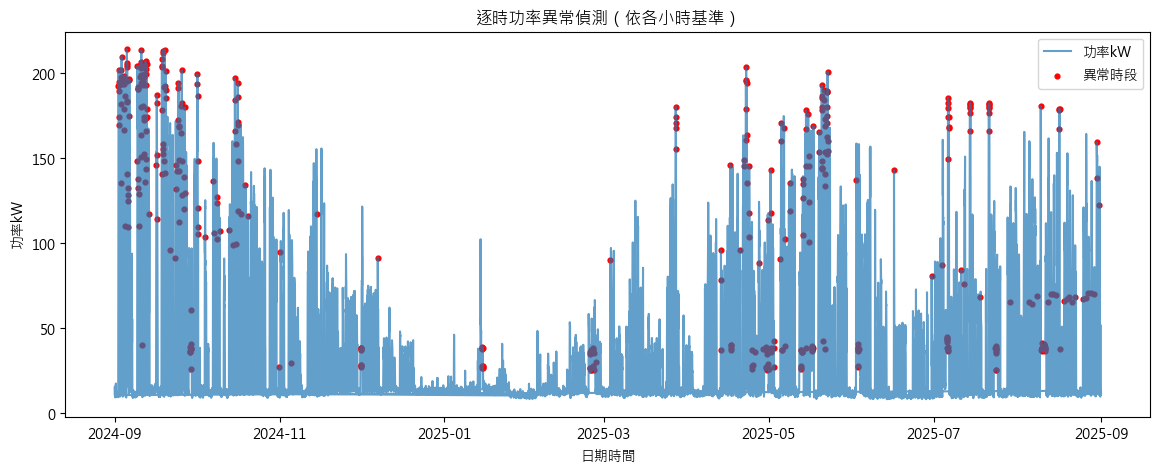

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(hourly["日期時間"], hourly["功率kW"], label="功率kW", alpha=0.7)
plt.scatter(hourly_anomaly2["日期時間"], hourly_anomaly2["功率kW"],
            color="red", s=12, label="異常時段")

plt.title("逐時功率異常偵測（依各小時基準）")
plt.xlabel("日期時間")
plt.ylabel("功率kW")
plt.legend()
plt.show()

異常時段其超過之閾值

In [23]:
hourly["excess"] = hourly["功率kW"] - hourly["threshold"]

top_anomaly = hourly.loc[hourly["anomaly_better"]].sort_values("excess", ascending=False)

print(top_anomaly[["日期時間", "功率kW", "threshold", "excess"]].head(20))

                    日期時間    功率kW   threshold      excess
8288 2024-09-10 21:00:00  205.27   99.538576  105.731424
8287 2024-09-10 20:00:00  213.70  113.470637  100.229363
8479 2024-09-18 20:00:00  211.99  113.470637   98.519363
8478 2024-09-18 19:00:00  213.30  118.828992   94.471008
6688 2025-07-06 07:00:00  149.83   56.549659   93.280341
8335 2024-09-12 20:00:00  205.48  113.470637   92.009363
6689 2025-07-06 08:00:00  179.46   88.285978   91.174022
8504 2024-09-19 21:00:00  190.40   99.538576   90.861424
8503 2024-09-19 20:00:00  201.40  113.470637   87.929363
8311 2024-09-11 20:00:00  197.85  113.470637   84.379363
8646 2024-09-25 19:00:00  201.79  118.828992   82.961008
5618 2025-05-22 19:00:00  201.09  118.828992   82.261008
8310 2024-09-11 19:00:00  199.94  118.828992   81.111008
8336 2024-09-12 21:00:00  179.05   99.538576   79.511424
1184 2024-10-19 07:00:00  134.28   56.549659   77.730341
8309 2024-09-11 18:00:00  174.21   98.306473   75.903527
4897 2025-04-22 19:00:00  194.6

夜間異常

In [24]:
night_anomaly = hourly_anomaly2[hourly_anomaly2["hour"].between(0,5)]

print("夜間異常數量：", len(night_anomaly))
print(night_anomaly.head(20))

夜間異常數量： 87
                    日期時間  hour   功率kW  threshold source_file
336  2025-01-15 00:00:00     0  38.63  24.495557       1.xls
337  2025-01-15 01:00:00     1  39.09  23.863284       1.xls
338  2025-01-15 02:00:00     2  38.19  23.251485       1.xls
339  2025-01-15 03:00:00     3  38.52  22.059239       1.xls
340  2025-01-15 04:00:00     4  27.80  23.058445       1.xls
341  2025-01-15 05:00:00     5  27.32  22.673666       1.xls
1589 2024-11-05 03:00:00     3  29.42  22.059239      11.xls
2210 2024-12-01 00:00:00     0  38.44  24.495557      11.xls
2211 2024-12-01 00:00:00     0  38.44  24.495557      12.xls
2212 2024-12-01 01:00:00     1  28.42  23.863284      12.xls
2213 2024-12-01 02:00:00     2  28.32  23.251485      12.xls
2214 2024-12-01 03:00:00     3  37.56  22.059239      12.xls
2215 2024-12-01 04:00:00     4  38.15  23.058445      12.xls
2216 2024-12-01 05:00:00     5  38.63  22.673666      12.xls
3508 2025-02-24 00:00:00     0  26.92  24.495557       2.xls
3509 2025-02-

尖峰轉移
定義「正常基載」 1.夜間平均用電 2. 找「異常基載」，不該高卻變高 3.看「基載趨勢」，有沒有變壞 / 改變

        date  base_load_kw  month
0 2024-09-01       12.4075      9
1 2024-09-02       10.9600      9
2 2024-09-03       12.5950      9
3 2024-09-04       11.9000      9
4 2024-09-05       12.4025      9


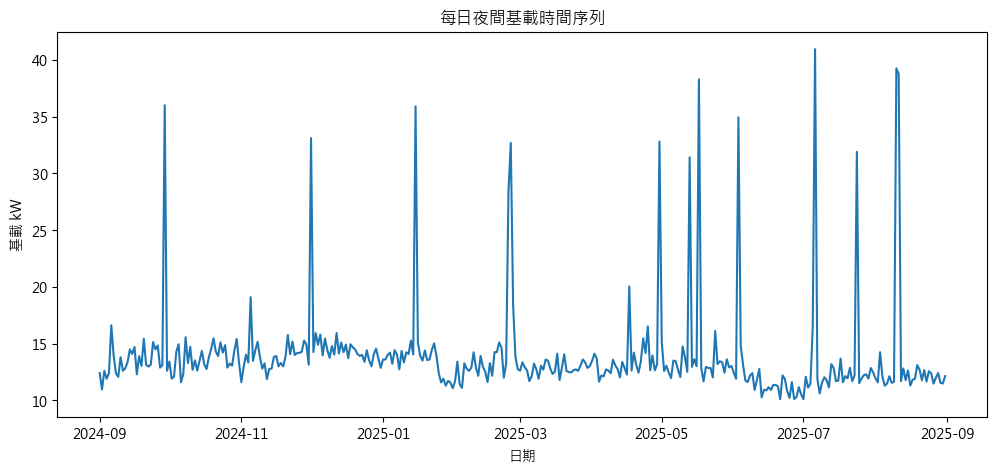

基載異常門檻： 22.5229406799291
          date  base_load_kw  month
28  2024-09-29       36.0025      9
91  2024-12-01       33.1125     12
136 2025-01-15       35.9000      1
176 2025-02-24       28.3950      2
177 2025-02-25       32.6750      2
241 2025-04-30       32.8050      4
254 2025-05-13       31.4150      5
258 2025-05-17       38.2900      5
275 2025-06-03       34.9400      6
308 2025-07-06       40.9400      7
326 2025-07-24       31.8975      7
343 2025-08-10       39.2575      8
344 2025-08-11       38.7700      8


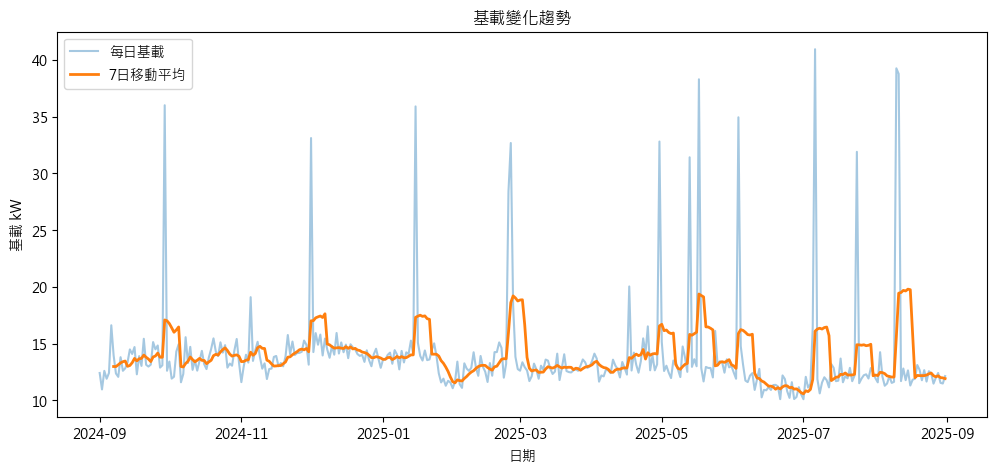

In [28]:
#每日基載
hourly["date"] = pd.to_datetime(hourly["日期時間"]).dt.date
hourly["month"] = pd.to_datetime(hourly["日期時間"]).dt.month
hourly["hour"] = pd.to_datetime(hourly["日期時間"]).dt.hour

daily_base = hourly.loc[hourly["hour"].between(1, 4)].groupby("date")["功率kW"].mean().reset_index()
daily_base.columns = ["date", "base_load_kw"]
daily_base["date"] = pd.to_datetime(daily_base["date"])
daily_base["month"] = daily_base["date"].dt.month

print(daily_base.head())
#基載時間序列
plt.figure(figsize=(12,5))
plt.plot(daily_base["date"], daily_base["base_load_kw"])
plt.title("每日夜間基載時間序列")
plt.xlabel("日期")
plt.ylabel("基載 kW")
plt.show()
#每日基載
base_mean = daily_base["base_load_kw"].mean()
base_std = daily_base["base_load_kw"].std()
base_threshold = base_mean + 2 * base_std

base_anomaly = daily_base[daily_base["base_load_kw"] > base_threshold]

print("基載異常門檻：", base_threshold)
print(base_anomaly.head(20))
#看基載是否慢慢上升
daily_base["base_roll7"] = daily_base["base_load_kw"].rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_base["date"], daily_base["base_load_kw"], alpha=0.4, label="每日基載")
plt.plot(daily_base["date"], daily_base["base_roll7"], linewidth=2, label="7日移動平均")
plt.title("基載變化趨勢")
plt.xlabel("日期")
plt.ylabel("基載 kW")
plt.legend()
plt.show()

夜間基載分析顯示，建築正常基載約為 12–14 kW，整體趨勢穩定，未呈現長期上升現象，顯示設備基礎耗能未明顯惡化。

然而，在多個日期出現顯著異常基載（30–40 kW），遠高於統計門檻（22.6 kW），顯示夜間存在非預期之高耗電行為。此類異常並非持續發生，而是間歇性出現，推測與設備未關閉、系統排程異常或特殊使用行為（如夜間作業）有關。

整體而言，本系統主要問題並非設備效率下降，而是「操作與控制策略不穩定」，具備明顯節能優化空間。

總結

📘 NTU 新生大樓能源分析總覽
📊 總覽分析結果

🔹 1. 星期平均用電 (kWh)：
weekday
星期一    1071.628113
星期二    1121.227115
星期三    1065.875577
星期四    1019.346346
星期五     827.169808
星期六     563.576731
星期日     503.597170
Name: energy_kWh, dtype: float64


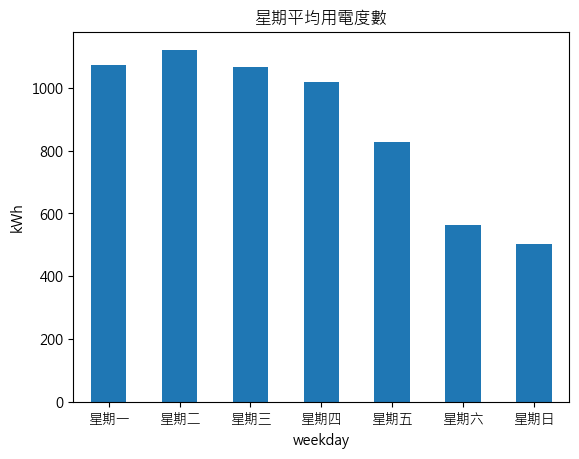


🔹 2. 假期 vs 非假期平均功率 (kW)：
暑假       861.807381
寒假       338.075179
非寒暑假    1023.084425
dtype: float64


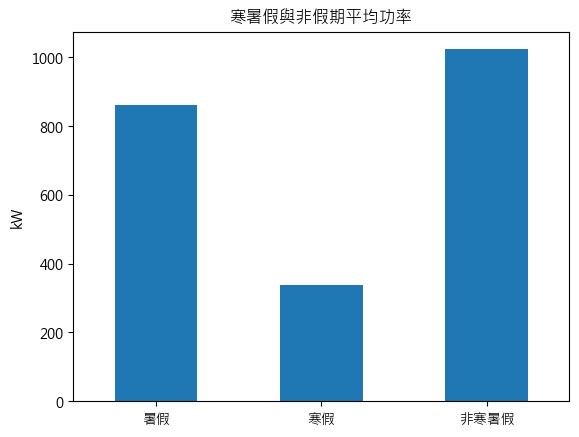


🔹 3. 日夜用電比較：
夜間基載平均 kW： 13.84537971805366
白天時段平均 kW： 63.55256967840735
日夜比： 4.590164442766281

🔹 4. 異常偵測結果：
改良後異常數量： 433

🔹 5. Top 10 異常時段：
                    日期時間    功率kW   threshold      excess
8288 2024-09-10 21:00:00  205.27   99.538576  105.731424
8287 2024-09-10 20:00:00  213.70  113.470637  100.229363
8479 2024-09-18 20:00:00  211.99  113.470637   98.519363
8478 2024-09-18 19:00:00  213.30  118.828992   94.471008
6688 2025-07-06 07:00:00  149.83   56.549659   93.280341
8335 2024-09-12 20:00:00  205.48  113.470637   92.009363
6689 2025-07-06 08:00:00  179.46   88.285978   91.174022
8504 2024-09-19 21:00:00  190.40   99.538576   90.861424
8503 2024-09-19 20:00:00  201.40  113.470637   87.929363
8311 2024-09-11 20:00:00  197.85  113.470637   84.379363


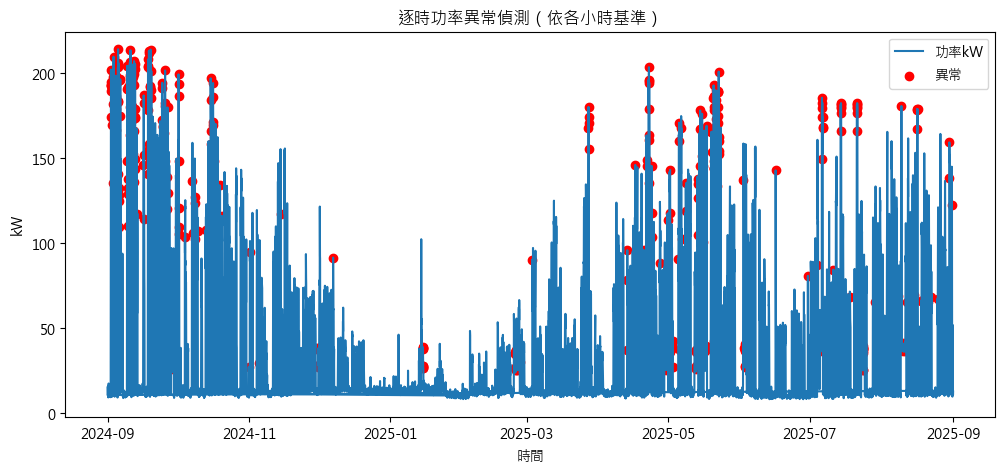

In [26]:
print("📘 NTU 新生大樓能源分析總覽")
print("="*50)
print("📊 總覽分析結果")
print("="*50)

# =========================
# 1. 星期平均用電
# =========================
print("\n🔹 1. 星期平均用電 (kWh)：")
print(weekday_avg)

weekday_avg.plot(kind="bar", title="星期平均用電度數")
plt.ylabel("kWh")
plt.xticks(rotation=0)
plt.show()


# =========================
# 2. 假期比較
# =========================
print("\n🔹 2. 假期 vs 非假期平均功率 (kW)：")
print(vacation_compare)

vacation_compare.plot(kind="bar", title="寒暑假與非假期平均功率")
plt.ylabel("kW")
plt.xticks(rotation=0)
plt.show()


# =========================
# 3. 日夜比
# =========================
print("\n🔹 3. 日夜用電比較：")
print("夜間基載平均 kW：", night_base)
print("白天時段平均 kW：", day_load)
print("日夜比：", day_load / night_base if night_base != 0 else None)


# =========================
# 4. 異常偵測（逐時）
# =========================
print("\n🔹 4. 異常偵測結果：")
print("改良後異常數量：", hourly["anomaly_better"].sum())


# =========================
# 5. 顯示最嚴重異常
# =========================
print("\n🔹 5. Top 10 異常時段：")
top_anomaly = hourly.loc[hourly["anomaly_better"]].copy()
top_anomaly["excess"] = top_anomaly["功率kW"] - top_anomaly["threshold"]

print(top_anomaly.sort_values("excess", ascending=False)[
    ["日期時間", "功率kW", "threshold", "excess"]
].head(10))


# =========================
# 6. 異常視覺化
# =========================
plt.figure(figsize=(12,5))
plt.plot(hourly["日期時間"], hourly["功率kW"], label="功率kW")

anomaly_points = hourly[hourly["anomaly_better"]]
plt.scatter(anomaly_points["日期時間"], anomaly_points["功率kW"],
            color="red", label="異常")

plt.legend()
plt.title("逐時功率異常偵測（依各小時基準）")
plt.xlabel("時間")
plt.ylabel("kW")
plt.show()

Cell 22：整理作業四題的重點結論

### 1. 週期性分析（工作日 vs 週末）
由星期平均用電結果可觀察到明顯的週期性差異。  
工作日（週一至週四）平均用電約為 1000–1100 kWh，而週末（週六、週日）下降至約 500–560 kWh，僅為工作日的一半左右。  

此結果顯示該建築具有典型的「工作導向用電型態」，用電主要集中於平日活動時段，週末顯著降低。

### 2. 假期效應（寒暑假）
從時間序列觀察可發現不同月份間存在用電差異，顯示假期與季節對用電具有一定影響。  
很明顯能看出是暑、寒假時使用電量都是低點，符合預期。

### 3. 其他能源使用行為
逐時資料分析顯示建築具有穩定夜間基載，且白天用電顯著高於夜間。  
日夜比約為 **4.59**，代表白天用電約為夜間的 4.6 倍。  

此外，晚間時段仍維持一定負載，顯示建築在非工作時間仍存在持續用電行為，可能來自設備運轉或部分使用需求。

### 4. 自動化異常偵測方法
本研究採用統計門檻法進行異常偵測：

- 日尺度：平均值 ± 2 倍標準差
- 逐時尺度：同一小時平均值 + 2 倍標準差（分時基準）

結果顯示，逐時基準可有效降低誤判，將異常數量由 598 筆降低至 **433 筆**，提升偵測準確性。

### 總結
本建築呈現明顯的週期性用電行為，其中「工作日與週末差異」為最顯著特徵。  
結合逐時分析，可進一步辨識日夜負載結構與異常時段。  
透過簡單統計方法即可建立有效的能源監測機制，具備實務應用價值。

### 5. 行事曆整合補充
本研究進一步整合臺大 113 學年度官方行事曆，將國定/校定假日、寒暑假、考試相關時段與選課/註冊期間併入每日用電資料。相較於直接以固定月份手動切分假期，此作法能更準確反映校園運作節奏，提升假期效應與異常事件判讀的可信度。